# Revised Baseline Diffusion Analysis

This notebook reproduces Phase I of the revised study. It distinguishes **active-spreader AUC** from direct simulated exposure, reports practical as well as statistical effects, and examines near-threshold, seed-placement, and structural-parameter sensitivity. The main experiment uses 100 matched graph realizations for each of the ER, WS, and BA topologies.

To regenerate the primary CSV files from scratch, run `python run_primary_experiments.py --trials 100 --workers 8`. The executed notebook reads the saved, reproducible outputs so that readers can inspect results without rerunning the full simulation.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal, levene, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
FIGURE_DIR = ROOT / 'figures'
OUTPUT_DIR = ROOT / 'analysis_outputs'
sys.path.insert(0, str(ROOT))
from misinformation_simulation import *
pd.set_option('display.max_columns', 60)
print('Project root:', ROOT)


Project root: /mnt/data/revision_work


In [2]:
baseline = pd.read_csv(DATA_DIR / 'baseline_results.csv')
graphs = pd.read_csv(DATA_DIR / 'graph_metrics.csv')
curves = pd.read_csv(DATA_DIR / 'baseline_curves.csv')
robust = pd.read_csv(DATA_DIR / 'robustness_baseline.csv')
seed_results = pd.read_csv(DATA_DIR / 'seed_placement_results.csv')
structural = pd.read_csv(DATA_DIR / 'structural_sensitivity.csv')
print('Baseline rows:', len(baseline))
print(baseline.groupby('topology').size())

Baseline rows: 300
topology
BA    100
ER    100
WS    100
dtype: int64


## Outcome definitions

`active_spreader_auc` is the time integral of the number of actively transmitting nodes. It is not called exposure. `unique_exposed_fraction` counts nodes that experienced at least one infected-susceptible contact attempt while still susceptible. `attempted_exposures` counts all such contact attempts, including repeated attempts.

In [3]:
metrics = ['t10','t50','peak_infected','final_size','active_spreader_auc','unique_exposed_fraction','attempted_exposures','repeat_exposures']
summary = baseline.groupby('topology')[metrics].agg(['mean','std','median'])
summary

t10                     t50                  peak_infected  \
          mean       std median   mean       std median          mean   
topology                                                                
BA        4.60  0.921132    4.0   7.51  0.958692    7.0        736.86   
ER        5.88  0.670896    6.0   9.83  0.779212   10.0        730.10   
WS        8.16  1.012248    8.0  16.03  1.403135   16.0        639.25   

                           final_size                  active_spreader_auc  \
                std median       mean       std median                mean   
topology                                                                     
BA        17.326351  737.0    0.99475  0.002476  0.995            19927.29   
ER        17.712918  731.0    0.99055  0.003456  0.991            19784.86   
WS        21.141359  639.0    0.99971  0.000924  1.000            20039.24   

                              unique_exposed_fraction                   \
                 std   median                    mean       std median   
topology                                                                 
BA        625.356646  19883.0                 0.99500  0.000000  0.995   
ER        655.272648  19815.0                 0.99258  0.001558  0.993   
WS        673.933608  20017.5                 0.99498  0.000200  0.995   

         attempted_exposures                     repeat_exposures              \
                        mean         std  median             mean         std   
topology                                                                        
BA                   7413.55  183.137437  7421.5          6418.55  183.137437   
ER                   7431.09  177.528834  7434.5          6438.51  177.776531   
WS                   7478.76  182.964705  7480.5          6483.78  182.948499   

                  
          median  
topology          
BA        6426.5  
ER        6441.0  
WS        6485.5

In [4]:
rows=[]
for metric in metrics:
    groups=[baseline.loc[baseline.topology==t,metric].dropna() for t in ['BA','ER','WS']]
    F,p=f_oneway(*groups); df1=2; df2=sum(map(len,groups))-3
    eta2=(F*df1)/(F*df1+df2)
    H,pk=kruskal(*groups)
    rows.append({'outcome':metric,'F':F,'p':p,'eta_squared':eta2,'Kruskal_H':H,'Kruskal_p':pk})
tests=pd.DataFrame(rows)
tests['Holm_p']=multipletests(tests.p,method='holm')[1]
tests

,outcome,F,p,eta_squared,Kruskal_H,Kruskal_p,Holm_p
0,t10,419.897739,2.725873e-87,0.738739,226.803120,5.627665e-50,1.635524e-86
1,t50,1665.395104,3.957959e-162,0.918132,258.312947,8.092009e-57,3.166367e-161
2,peak_infected,840.183574,5.437090e-123,0.849800,202.172908,1.255194e-44,3.805963e-122
3,final_size,333.190316,1.289267e-76,0.691711,227.709700,3.576571e-50,6.446336e-76
4,active_spreader_auc,3.825720,2.288507e-02,0.025115,7.927684,1.899002e-02,6.865521e-02
5,unique_exposed_fraction,235.360020,5.645540e-62,0.613140,257.007884,1.553986e-56,2.258216e-61
6,attempted_exposures,3.467113,3.247586e-02,0.022815,6.764099,3.397775e-02,6.865521e-02
7,repeat_exposures,3.398468,3.472959e-02,0.022373,6.651443,3.594658e-02,6.865521e-02


The strongest and most stable baseline effect is diffusion speed: BA reaches both thresholds first, ER is intermediate, and WS is slowest. The high-transmission baseline is nearly saturated, so final-size and direct-exposure differences must be interpreted with the near-threshold sweeps below.

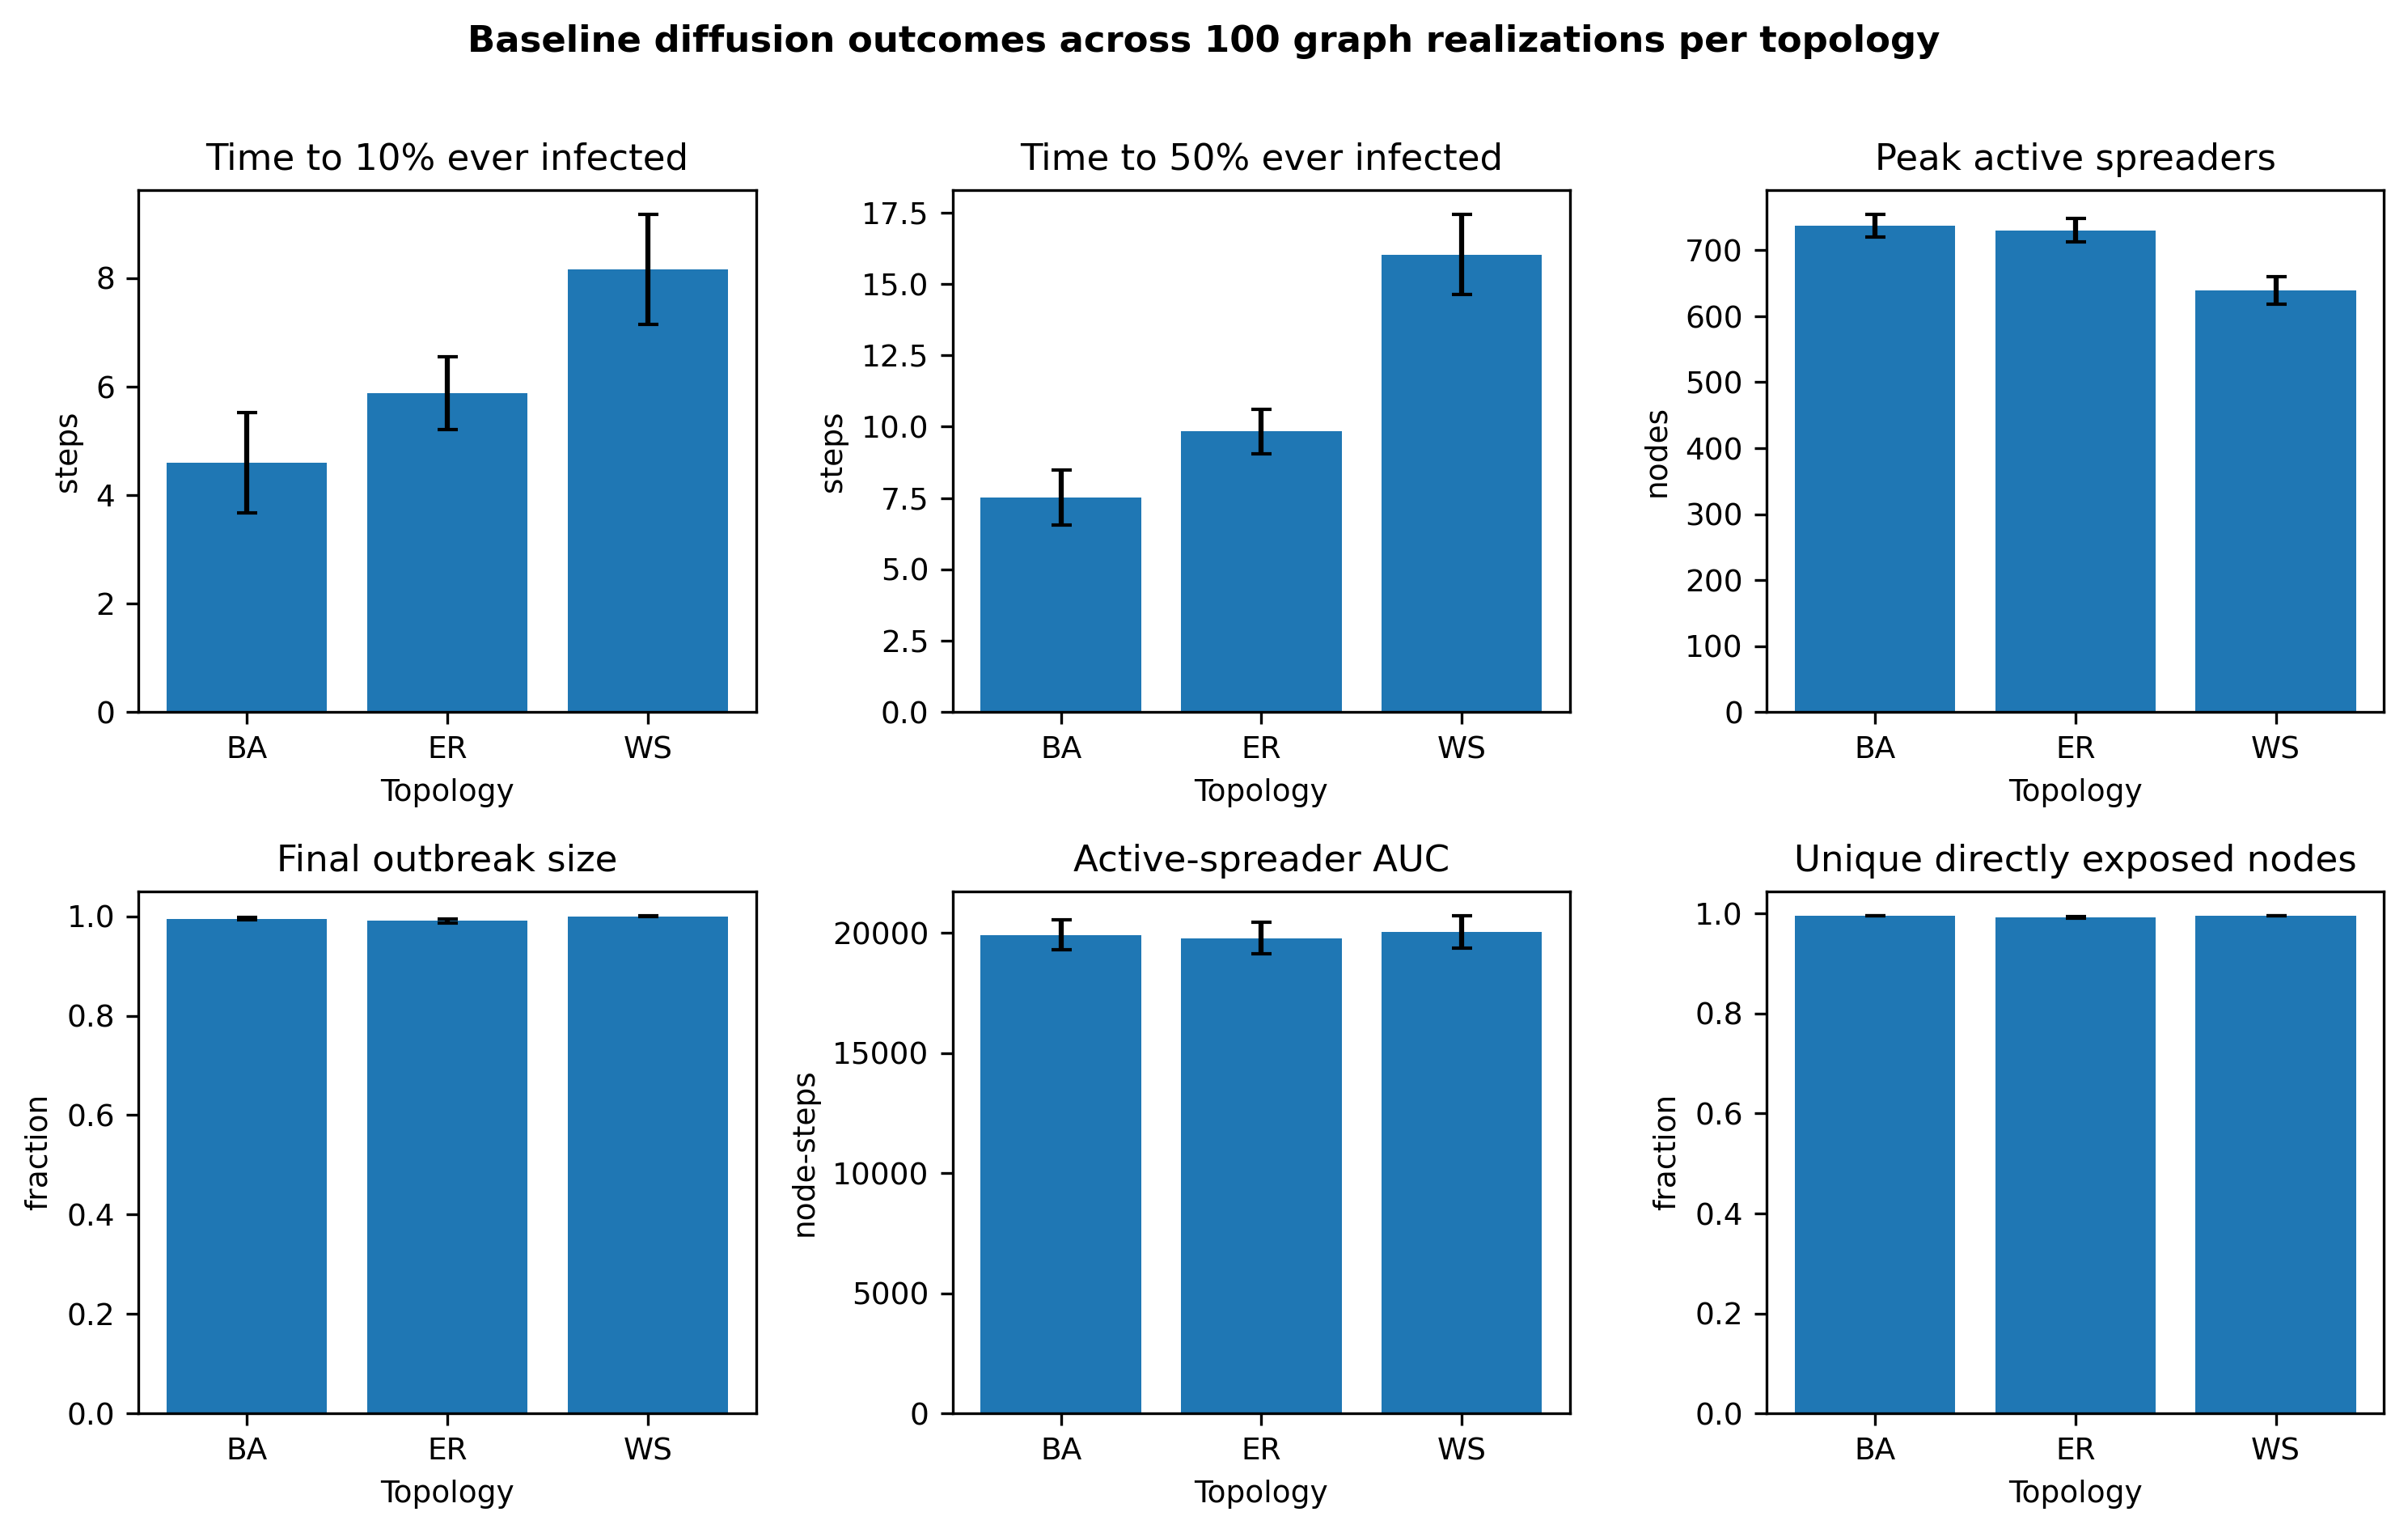

In [5]:
from IPython.display import Image, display
display(Image(filename=str(FIGURE_DIR/'figure_baseline_outcomes.png')))

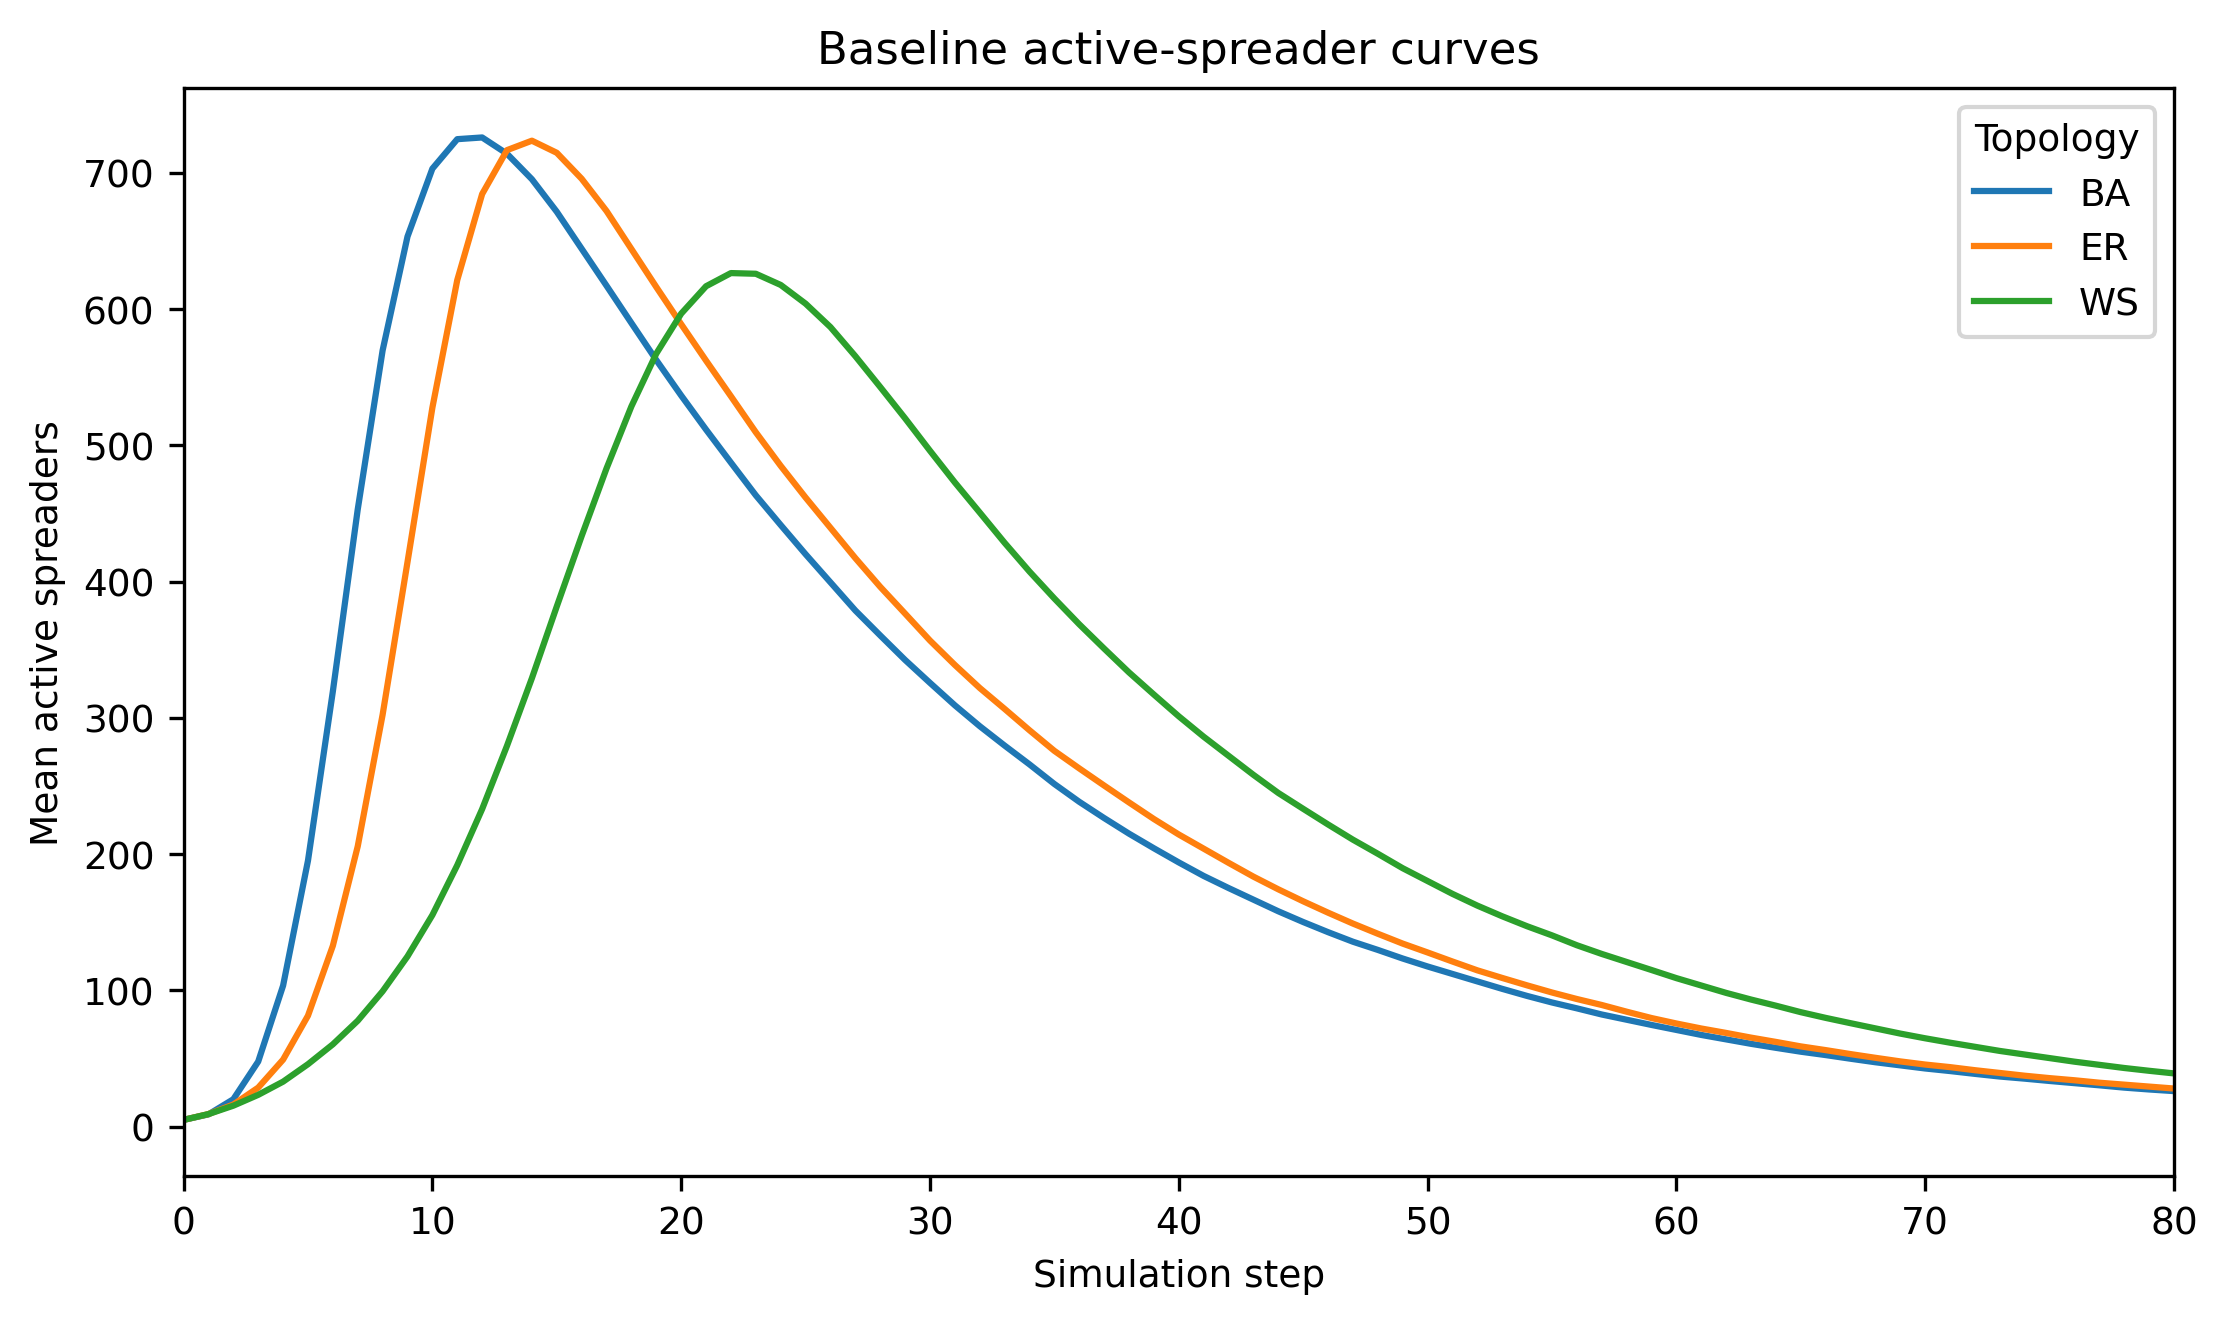

In [6]:
display(Image(filename=str(FIGURE_DIR/'figure_baseline_curves.png')))

## Near-threshold and recovery-rate sensitivity

In [7]:
near = (robust[robust.family=='beta_gamma']
        .groupby(['beta','gamma','topology'])[['t10','reached_50','final_size','unique_exposed_fraction']]
        .mean().reset_index())
near

,beta,gamma,topology,t10,reached_50,final_size,unique_exposed_fraction
0,0.005,0.05,BA,132.000000,0.00,0.02715,0.18775
1,0.005,0.05,ER,NaN,0.00,0.01335,0.07785
2,0.005,0.05,WS,NaN,0.00,0.00990,0.04160
3,0.005,0.10,BA,NaN,0.00,0.01440,0.11335
4,0.005,0.10,ER,NaN,0.00,0.00630,0.03485
5,0.005,0.10,WS,NaN,0.00,0.00685,0.03470
6,0.010,0.05,BA,68.357143,0.00,0.24275,0.68370
7,0.010,0.05,ER,188.000000,0.00,0.05475,0.23940
8,0.010,0.05,WS,NaN,0.00,0.01750,0.05620
9,0.010,0.10,BA,50.000000,0.00,0.02645,0.17110


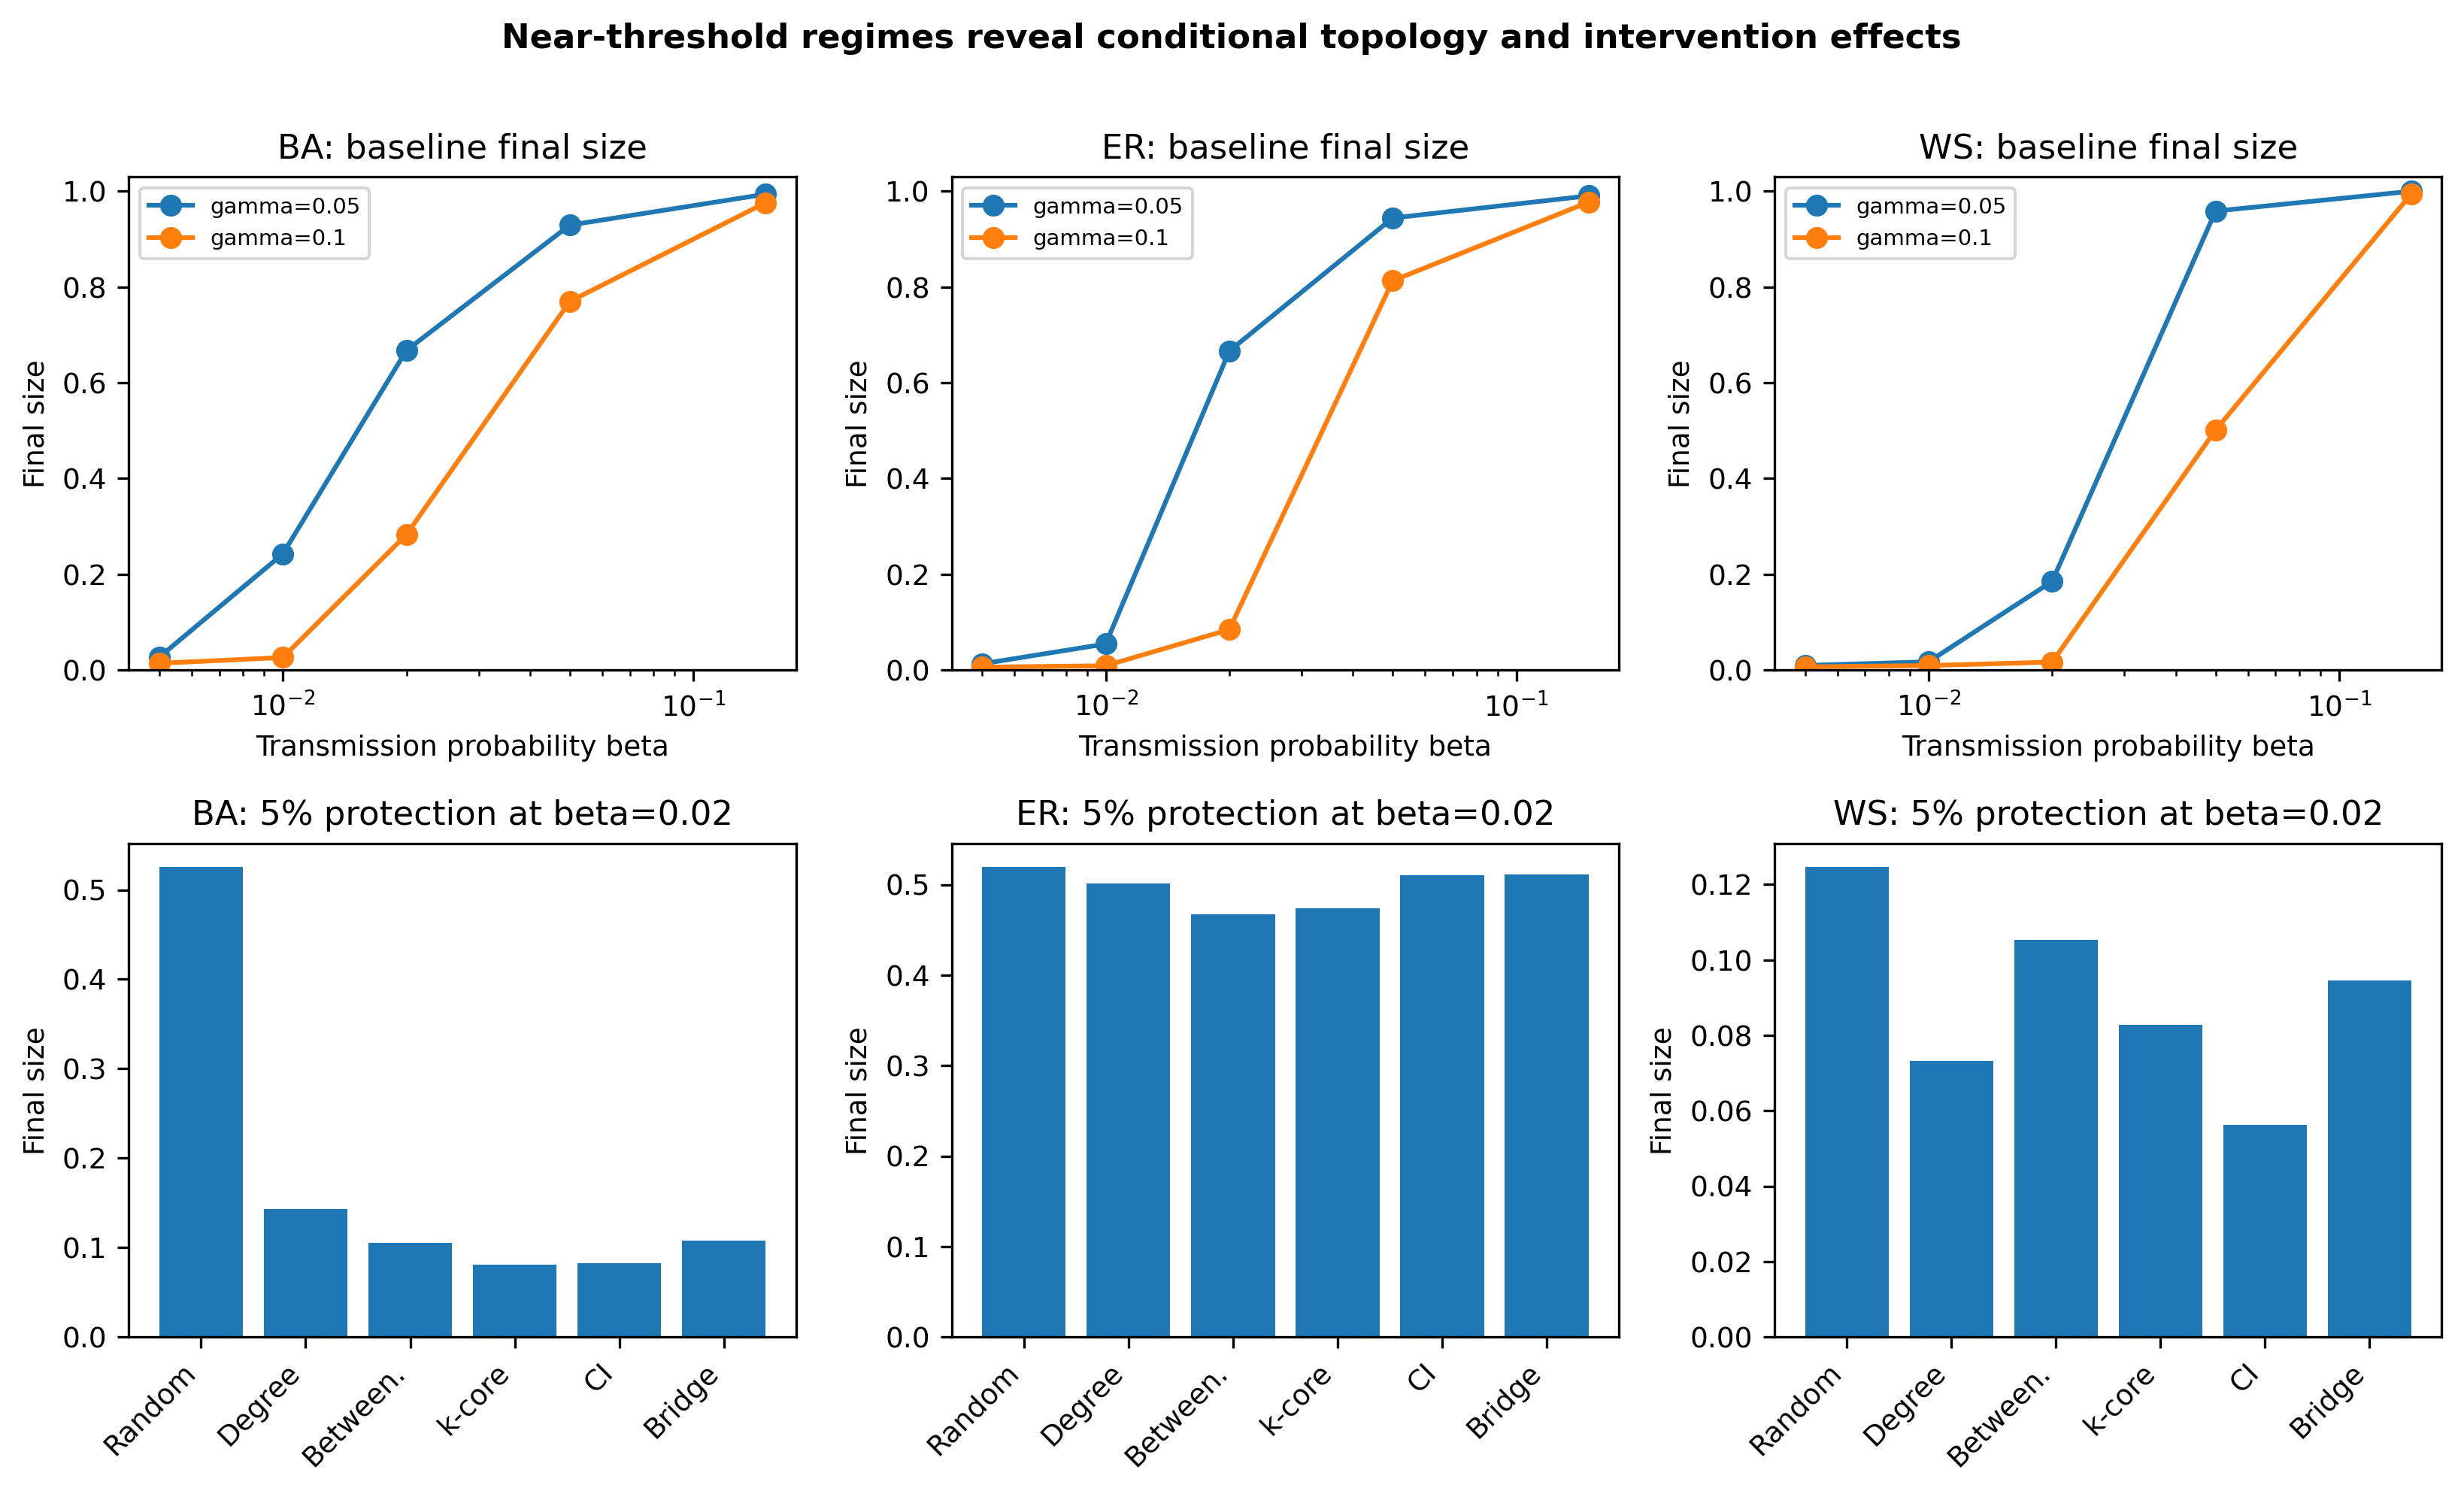

In [8]:
display(Image(filename=str(FIGURE_DIR/'figure_near_threshold.png')))

## Seed placement and network-structure sensitivity

In [9]:
seed_results.groupby(['topology','seed_mode'])[['t10','t50','reached_50','final_size']].mean()

t10        t50  reached_50  final_size
topology seed_mode                                            
BA       bridge        2.00   5.050000        1.00     0.99405
         high_degree   2.05   5.050000        1.00     0.99600
         peripheral    4.25   7.100000        1.00     0.99540
         random        4.30   7.150000        1.00     0.99490
ER       bridge        4.65   8.700000        1.00     0.99040
         high_degree   4.20   8.150000        1.00     0.99090
         peripheral   11.00  15.052632        0.95     0.94280
         random        6.20  10.100000        1.00     0.98950
WS       bridge        7.25  14.750000        1.00     0.99980
         high_degree   6.75  14.150000        1.00     0.99965
         peripheral    9.70  17.500000        1.00     0.99995
         random        7.85  15.300000        1.00     0.99975

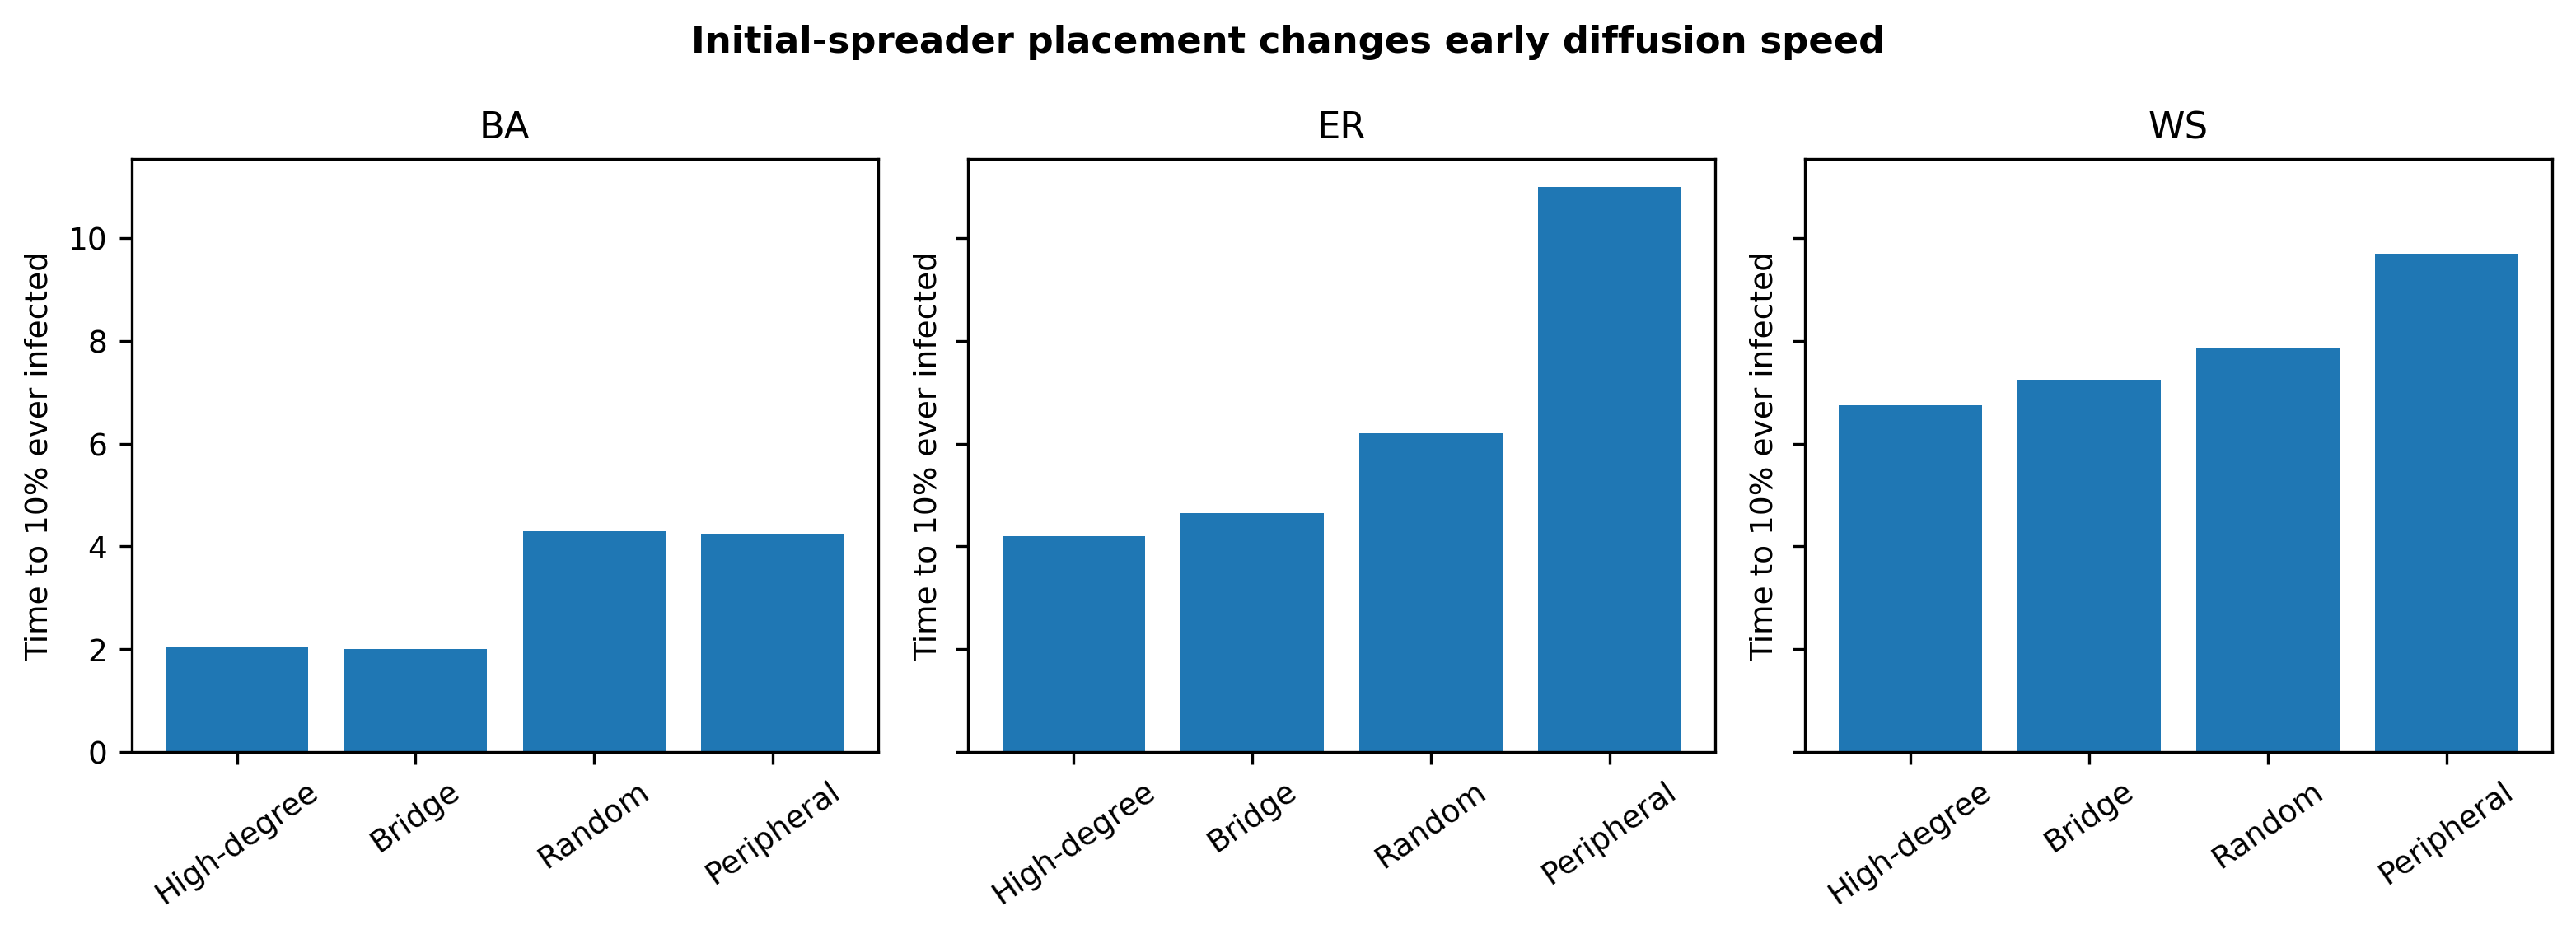

In [10]:
display(Image(filename=str(FIGURE_DIR/'figure_seed_placement.png')))

In [11]:
structural.groupby(['family','value','topology'])[['mean_degree','clustering','t10','reached_50','final_size']].mean().head(40)

mean_degree  clustering    t10  reached_50  \
family      value   topology                                               
ba_m        2.00    BA            3.99200    0.026477   5.90         1.0   
            3.00    BA            5.98200    0.029503   4.55         1.0   
            5.00    BA            9.95000    0.040088   3.40         1.0   
mean_degree 4.00    BA            3.99200    0.026000   6.15         1.0   
                    ER            4.01180    0.003449   8.75         1.0   
                    WS            4.00000    0.375409  14.20         1.0   
            6.00    BA            5.98200    0.033552   4.60         1.0   
                    ER            6.02760    0.005937   5.90         1.0   
                    WS            6.00000    0.440972   8.35         1.0   
            10.00   BA            9.95000    0.040582   3.35         1.0   
                    ER            9.98960    0.010145   4.10         1.0   
                    WS           10.00000    0.490701   5.00         1.0   
n           500.00  BA            5.96400    0.052051   4.10         1.0   
                    ER            5.98940    0.011607   4.65         1.0   
                    WS            6.00000    0.443976   5.85         1.0   
            1000.00 BA            5.98200    0.031344   4.60         1.0   
                    ER            5.99400    0.005358   5.95         1.0   
                    WS            6.00000    0.444969   8.15         1.0   
            2000.00 BA            5.99100    0.017854   5.45         1.0   
                    ER            6.01935    0.002878   7.50         1.0   
                    WS            6.00000    0.443221  10.70         1.0   
sbm_mixing  0.02    SBM           5.95940    0.022698   5.95         1.0   
            0.10    SBM           6.00240    0.017580   6.10         1.0   
            0.30    SBM           5.98300    0.009974   6.40         1.0   
ws_rewire   0.01    WS            6.00000    0.583103  10.65         1.0   
            0.10    WS            6.00000    0.444335   8.30         1.0   
            0.50    WS            6.00000    0.078578   6.45         1.0   

                              final_size  
family      value   topology              
ba_m        2.00    BA          0.967950  
            3.00    BA          0.995350  
            5.00    BA          0.999750  
mean_degree 4.00    BA          0.969500  
                    ER          0.950550  
                    WS          0.984550  
            6.00    BA          0.995500  
                    ER          0.990800  
                    WS          0.999550  
            10.00   BA          0.999800  
                    ER          0.999400  
                    WS          1.000000  
n           500.00  BA          0.993400  
                    ER          0.990900  
                    WS          0.999400  
            1000.00 BA          0.995100  
                    ER          0.990900  
                    WS          1.000000  
            2000.00 BA          0.995150  
                    ER          0.990300  
                    WS          0.999875  
sbm_mixing  0.02    SBM         0.989850  
            0.10    SBM         0.990800  
            0.30    SBM         0.990900  
ws_rewire   0.01    WS          0.998100  
            0.10    WS          0.999700  
            0.50    WS          0.999450

## Reproducibility record

Graph seeds, trial numbers, topology parameters, and every recorded outcome are stored in the CSV files in `data/`. The simulation engine is `misinformation_simulation.py`.